# Ejercicio de Feedback Unidad 1, 2, 3:

#### Juan Manuel


**************************************************************

# Primera Parte

En primer lugar se importan las librerías necesarias para el análisis:

In [1]:
# Se importan las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Configuración de estilo para los gráficos
plt.style.use('seaborn-v0_8-whitegrid')

Se cargan los dataset  `Hogwards - 20241T.csv`, `Hogwards - 20242T.csv` y `Hogwards - 20243T.csv`, en los que cada uno contiene los Data Products pertenecientes a cada trimestre. Para ello se creó una lista comprimida que carga cada uno de ellos y les asigna una columna `Trimestre` para poder identificar el mismo a la hora de combinarlos en un único dataset.

In [2]:
# Creo una lista comprimida donde cargo los archivos CSV y asigno el trimestre correspondiente,
# añadiendo una nueva columna llamada "Trimestre". Esto, será de utilidad para los análisis posteriores.
lista_dfs = [
    pd.read_csv(f'Hogwards - 2024{d}T.csv').assign(Trimestre=f'T{d}')
    for d in range(1,4)
]

# Muestro con head las primeras filas de cada DataFrame cargado para comprobar que se han leído correctamente
#for i, df in enumerate(lista_dfs, start=1):
    # print(f"DataFrame Trimestre {i}:")
    # display(df.head())

# Concateno los DataFrames en uno solo
df_combinado = pd.concat(lista_dfs, ignore_index=True)


> ❓ **_Estado actual de los Data Products:_**  ¿Cuántos  Data  Products  existen  actualmente?  Desglosa  esta  información  por dominio y estado. Queremos saber qué áreas de Hogwarts están mejor (y peor) preparadas.

In [3]:
# Todos los Data Products cada uno en su estado más reciente
df_actual = df_combinado.drop_duplicates(subset=['ID'], keep='last')
# print(f"Data Products actuales: {len(df_actual)}")

# Es posible hacerlo directamente agrupando por 'Domain' y 'Status' para obtener el conteo de Data Products en cada 
# estado por dominio de la forma group = df_actual.groupby(['Domain', 'Status']).size(), pero en este caso opté 
# por una tabla cruzada para una mejor visualización.
tb_dominio_estado = pd.crosstab(
    df_actual['Domain'],
    df_actual['Status'],
    margins=True,
    margins_name='Total'
)

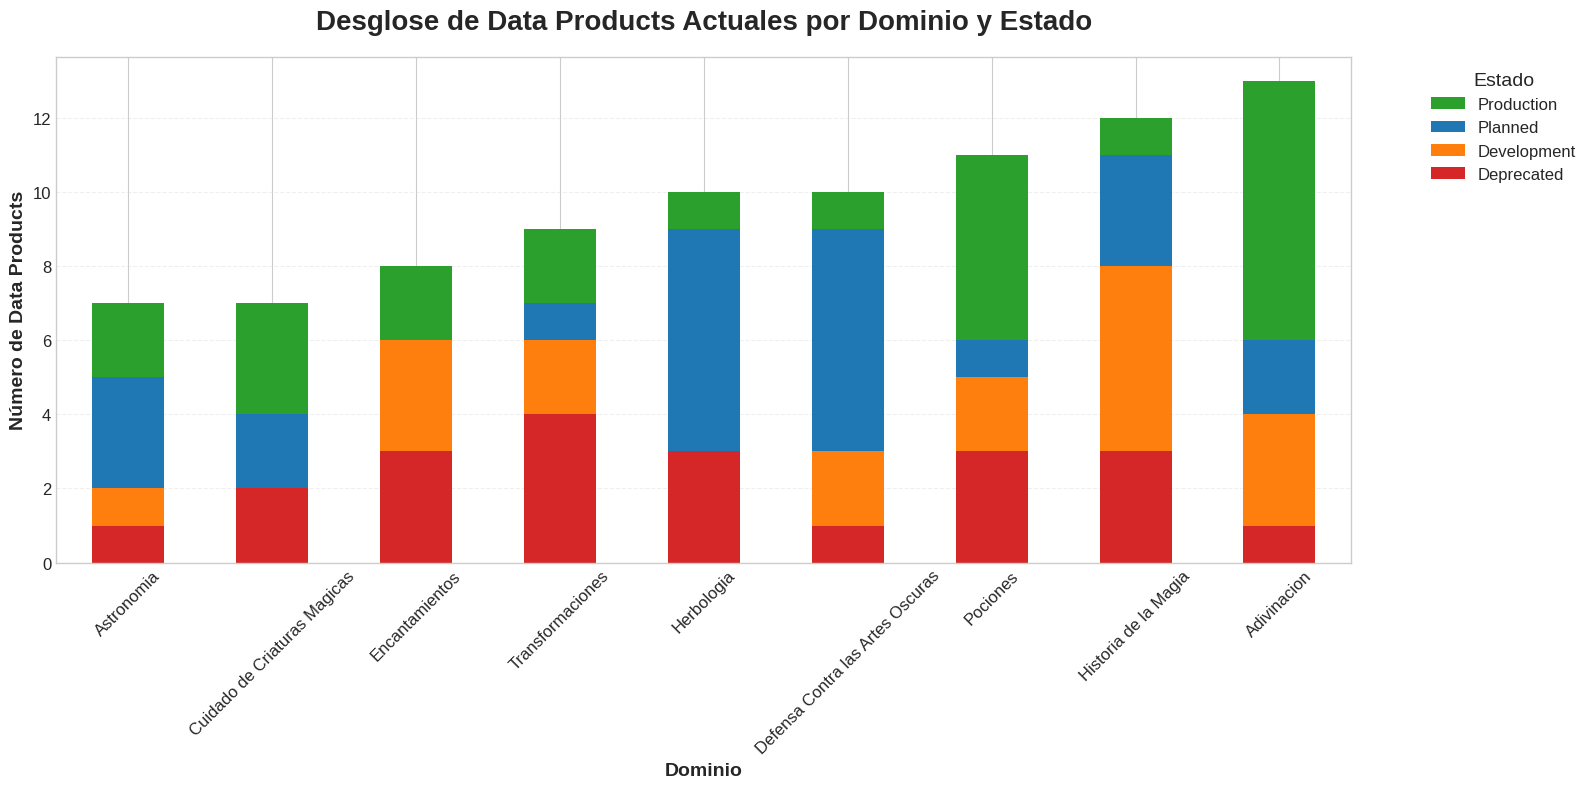

In [4]:
# Elimino marginales
tb_grafico_sorted = tb_dominio_estado.drop('Total', axis=0).copy()

# Ordeno el DataFrame (las filas 'Domain') por la columna marginal 'Total' de mayor a menor
tb_grafico_sorted = tb_grafico_sorted.sort_values(by='Total', ascending=True)

# Eliminamo la columna marginal 'Total' para que solo queden los estados
tb_grafico_sorted = tb_grafico_sorted.drop(columns='Total')

# Reordeno las columnas de peor estado a mejor
orden_columnas = ['Deprecated', 'Development', 'Planned', 'Production']
tb_grafico = tb_grafico_sorted.reindex(columns=orden_columnas)

# Defino paleta de colores para ensalzar casos favorables o no favorables
colores = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c']

# Creo la figura le paso los datos y personalizo el tipo de gráfico (en este caso se ajusta bien
# un gráfico de barras apiladas), el stacked que hace que las barras se apilen, los colores que definí
# y el eje actual con ax=plt.gca() para que se dibuje en la figura creada.
fig, ax = plt.subplots(figsize=(16, 8))
tb_grafico.plot(
    kind='bar',
    stacked=True,
    color=colores,
    ax=ax # Usar el eje actual
)

# Defino el tituilo y las etiquetas de los ejes con personalización de fuente
ax.set_title('Desglose de Data Products Actuales por Dominio y Estado', 
          fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Dominio', fontsize=14, fontweight='bold')
ax.set_ylabel('Número de Data Products', fontsize=14, fontweight='bold')

# Invierto la leyenda para que coincida con el apilamiento y quede bonito visualmente
handles, labels = plt.gca().get_legend_handles_labels()
ax.legend(
    handles[::-1], 
    labels[::-1],
    title='Estado',           # Título
    bbox_to_anchor=(1.05, 1), # Posición fuera
    loc='upper left', 
    fontsize=12, 
    title_fontsize=14    
)

ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
fig.tight_layout()

# Defino una variable para poder reutilizar el gráfico posteriormente
grafico_dp_estado = fig

> ❓ **_Análisis trimestral de los Data Products en estado "Planned" o "Production:_**
> - ¿Cuántos de estos cumplen con las normas de compliance?
> - ¿Cuántos usuarios están utilizando estos Data Products en cada área?
> - ¿Cuál es el promedio de usuarios por área?
> - Y  en  aquellos  que  no  cumplen  con  compliance,  ¿cuántos  usuarios  tienen  de 
todas formas? (¡Esto es importante para identificar posibles brechas de 
seguridad!).
>

In [24]:
# Defino diccionarios para almacenar tablas resultado por trimestre
usuarios_total_promedio_t = {}
domain_summary = {}
# Inicializamos una lista para recolectar los datos de los 3 trimestres
compliance_data = []
usuarios_conectados_t = {}

for trimestre in ['T1', 'T2', 'T3']:
    #print(f"\n{'='*60}")
    #print(f"  TRIMESTRE {trimestre}")
    #print(f"{'='*60}")
    
    # Filtro por trimestre para obtener cada DataFrame correspondiente
    df_trimestre = df_combinado[df_combinado['Trimestre'] == trimestre]

    # Primero filtro los Data Products que están en estado 'Planned' o 'Production'
    pp_subset = df_trimestre.loc[df_trimestre['Status'].isin(['Planned', 'Production'])]

    # Ahora cuento cuántos de estos cumplen con las normas de compliance
    compliance_count = pp_subset['IsCompliance'].sum()
    #print(f"Número de Data Products en estado 'Planned' o 'Production' que cumplen con las normas de compliance: {compliance_count}")

    # Cuento usuarios que están utilizando estos Data Products en cada área
    usuarios = pp_subset.groupby('Domain')['NumberUsers']
    usuarios_total = usuarios.sum().to_frame(name='TotalUsuarios')
    #display(usuarios_total)

    # Promedio de usuarios por área
    usuarios_promedio = usuarios.mean().to_frame(name='PromedioUsuarios')
    #display(usuarios_promedio)

    # Almaceno los totales y promedios en el diccionario
    usuarios_total_promedio_t[trimestre] = {
        'TotalUsuarios': usuarios_total,
        'PromedioUsuarios': usuarios_promedio
    }

    # En aquellos que no cumplen compliance
    no_compliance_count = pp_subset['IsCompliance'] == False
    no_compliance_count = no_compliance_count.sum()
    #print(f"Número de Data Products en estado 'Planned' o 'Production' que NO cumplen con las normas de compliance: {no_compliance_count}")
    # Imprimo el número de usuarios conectados a estos Data Products por trimestre
    usuarios_conectados = pp_subset[pp_subset['IsCompliance'] == False].groupby('Domain')['NumberUsers'].sum()
    #print(f"Usuarios conectados a Data Products en estado 'Planned' o 'Production' que NO cumplen con las normas de compliance en {trimestre}:\n{usuarios_conectados}\n")
    usuarios_conectados_t[trimestre] = usuarios_conectados

    # Almaceno los resultados en la lista
    compliance_data.append({
        'Trimestre': trimestre,
        'DPs con Compliance': compliance_count,
        'DPs sin Compliance': no_compliance_count
    })


# Muestro la tabla resumen de compliance por trimestre
#compliance_summary = pd.DataFrame(compliance_data)
#display(compliance_summary)

In [25]:
# Creo una función para imprimir los resultados finales
def imprimir_p_p(usuarios_conectados_t):
    # Cojo la tabla de compliance
    tb_compliance_summary = pd.DataFrame(compliance_data).set_index('Trimestre')

    # Combino TotalUsuarios y PromedioUsuarios dentro de cada trimestre
    df_list_joined = []
    for trimestre in ['T1', 'T2', 'T3']:
        # Accedo a los DataFrames guardados en el diccionario anidado y los uno
        df_joined = usuarios_total_promedio_t[trimestre]['TotalUsuarios'].join(
            usuarios_total_promedio_t[trimestre]['PromedioUsuarios']
        )
        df_list_joined.append(df_joined)

    # Apilo los tres DataFrames unidos, usando el Trimestre como una nueva clave (MultiIndex)
    df_combined_raw = pd.concat(df_list_joined, keys=['T1', 'T2', 'T3'], names=['Trimestre', 'Domain'])

    # Uso el método unstack para que los Trimestres (T1, T2, T3) se muevan a las columnas
    domain_summary = df_combined_raw.unstack(level='Trimestre')

    # Muestro los resultados finales incluyendo texto con Markdown
    display(Markdown("### Resumen 1: Conteo de Data Products por Cumplimiento (Planned/Production)"))
    display(tb_compliance_summary)

    display(Markdown("### Resumen 2: Evolución de Usuarios por Dominio (Total y Promedio por Área)"))
    display(domain_summary)

In [26]:
def imprimir_no_compliance():
    # Imprimo el número de usuarios conectados a NO compliance por trimestre
    usuarios_conectados_df = pd.DataFrame(usuarios_conectados_t)
    # Añado marginal total
    usuarios_conectados_df.loc['Total'] = usuarios_conectados_df.sum()
    display(Markdown("### Resumen 3: Usuarios Conectados a Data Products en Estado No Compliance por Trimestre"))
    display(usuarios_conectados_df)

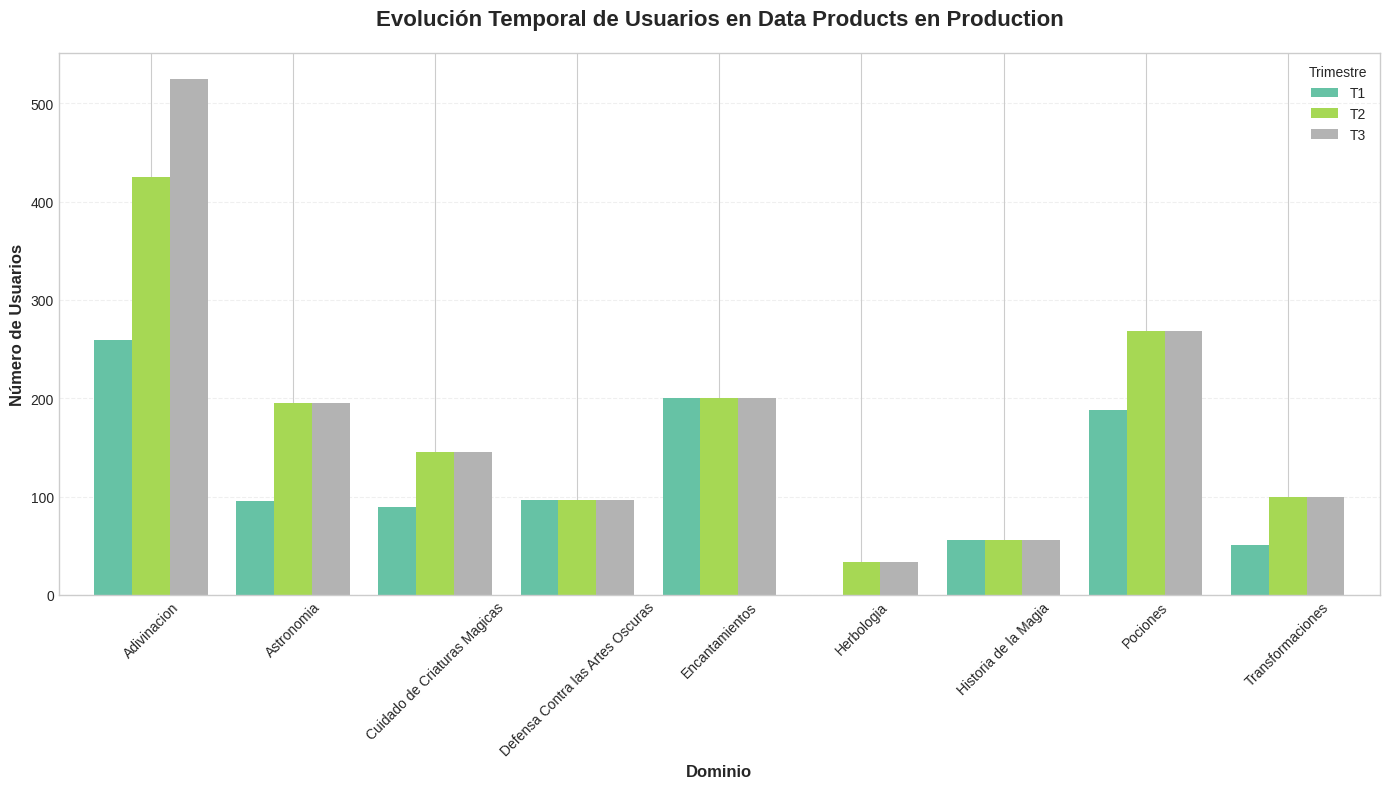

In [8]:
## Gráfico 2: Evolución temporal de usuarios en Data Products en Production
# Cojo lo que necesito del DataFrame combinado
production = df_combinado[df_combinado['Status'] == 'Production']
production_users = production.groupby(['Trimestre', 'Domain'])['NumberUsers'].sum().unstack(fill_value=0)

# Creo Figura y Eje para el subplot que me va a permitir mostrarla luego con una variable
fig2, ax = plt.subplots(figsize=(14, 8)) 

# Plot explícitamente en el eje 'ax'
production_users.T.plot(kind='bar', width=0.8, colormap='Set2', ax=ax) 

ax.set_title('Evolución Temporal de Usuarios en Data Products en Production', 
          fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Dominio', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Usuarios', fontsize=12, fontweight='bold')

ax.legend(title='Trimestre', loc='upper right', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

fig2.tight_layout()

grafica_dp_production_users = fig2


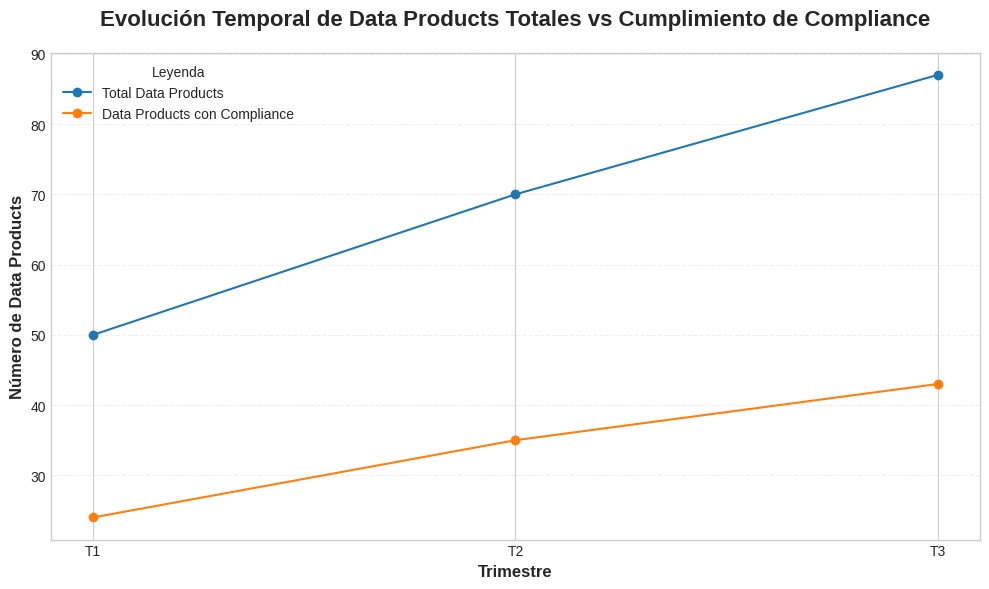

In [9]:
# Evolución temporal  de  Data  Products  totales  frente  a  aquellos  que  cumplen  con 
# compliance.
evolucion_total = df_combinado.groupby('Trimestre')['ID'].count()
evolucion_compliance = df_combinado[df_combinado['IsCompliance'] == True].groupby('Trimestre')['ID'].count()
fig3, ax = plt.subplots(figsize=(10, 6))
ax.plot(evolucion_total.index, evolucion_total.values, marker='o', label='Total Data Products')
ax.plot(evolucion_compliance.index, evolucion_compliance.values, marker='o', label='Data Products con Compliance')
ax.set_title('Evolución Temporal de Data Products Totales vs Cumplimiento de Compliance', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Trimestre', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Data Products', fontsize=12, fontweight='bold')
ax.legend(title='Leyenda', loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
fig3.tight_layout()
grafica_evolucion_owners = fig3


> ❓ **_Análisis trimestral de los Data Products "Deprecated":_**
> - ¿Cuántos Data Products en estado "Deprecated" hay en cada dominio?
> - ¿Cuántos usuarios siguen conectados a estos Data Products que, oficialmente, 
ya no están en servicio? 

In [31]:
deprecated_por_dominio_t = {}
usuarios_conectados_t = {}

# Como se van a analizar los productos deprecated, se filtran de primera instancia en el DataFrame combinado
df_deprecated = df_combinado[df_combinado['Status'] == 'Deprecated']
for trimestre in ['T1', 'T2', 'T3']:
    # Filtro por trimestre para obtener cada DataFrame correspondiente
    df_trimestre = df_deprecated[df_deprecated['Trimestre'] == trimestre]

    # Cuento cuántos Data Products en estado "Deprecated" hay en cada dominio
    deprecated_por_dominio = df_trimestre['Domain'].value_counts().sort_values(ascending=False).to_frame(name='Número de Data Products Deprecated')
    deprecated_por_dominio_t[trimestre] = deprecated_por_dominio
    #display(deprecated_por_dominio)

    # Cuento cuántos usuarios siguen conectados a estos Data Products que, oficialmente, ya no están en servicio
    usuarios_conectados = df_trimestre['NumberUsers'].sum()
    usuarios_conectados_t[trimestre] = usuarios_conectados
    #print(f"Número de usuarios conectados a Data Products en estado 'Deprecated' en {trimestre}: {usuarios_conectados}")

In [39]:
def imprimir_deprecated_por_dominio(deprecated_por_dominio_t, usuarios_conectados_t):
    for trimestre in deprecated_por_dominio_t:
        display(Markdown(f"#### Desglose de Data Products en estado {"Deprecated"} en {trimestre}"))
        display(Markdown(f"**Número de usuarios conectados a Data Products en estado 'Deprecated' en {trimestre}: {usuarios_conectados_t[trimestre]}**"))
        # Añado el total de DP deprecated
        display(deprecated_por_dominio_t[trimestre])

> ❓ **_Análisis de los funcionarios (Owners) por cada trimestre:_**
> - ¿Cuántos funcionarios están trabajando, y cuántos Data Products (por estado) 
tienen asignados?
> - En cada dominio, ¿quiénes son los tres Owners  con más usuarios en sus Data 
Products en estado "Planned" o "Production"? 
> - Por  otro  lado,  ¿quién  es  el  Owner  menos  productivo  en  cada  dominio?  Esto 
significa que tiene el mayor porcentaje de Data Products en estado 
"Deprecated"  sobre  el  total  que  le  han  asignado.  Si  hay  empate,  ¡queremos 
saber todos los nombres! 
> - Y  finalmente,  debido a la importancia de  la ubicuidad, ¿hay  algún funcionario 
que  esté trabajando en varios dominios a la vez? El Ministerio quiere saber si 
tiene a algún mago "polifacético" en su equipo.


In [13]:
tb_owner_estado_t = {}
top3_por_trimestre = {}
least_productive_master_list = {}
owners_multiples_t3 = {}

for trimestre in ['T1', 'T2', 'T3']:
    # Filtro por trimestre para obtener cada DataFrame correspondiente
    df_trimestre = df_combinado[df_combinado['Trimestre'] == trimestre]

    # Cuento el número de Owners únicos trabajando en ese trimestre
    #num_owners = df_trimestre['Owner'].nunique()
    #print(f"Número de Owners únicos trabajando en {trimestre}: {num_owners}")
    #dp_estado = df_trimestre.groupby(['Owner', 'Status']).size().unstack(fill_value=0)
    #display(dp_estado)
    
    tb_owner_estado = pd.crosstab(
        df_trimestre['Owner'],
        df_trimestre['Status'],
        margins=True,
        margins_name='Total'
    )
    tb_owner_estado_t[trimestre] = tb_owner_estado

    # Filtro aquellos DP en estado 'Planned' o 'Production'
    planned_production = df_trimestre[df_trimestre['Status'].isin(['Planned', 'Production'])]
    dominios = df_trimestre['Domain'].unique()

    # Defino una lista para almacenar los DataFrames de los top 3 por dominio
    trimestre_top3_list = []

    # Recorro cada dominio para obtener el top 3 de Owners por número de usuarios
    for dominio in dominios:
        # Filtro por dominio
        df_dominio = planned_production[planned_production['Domain'] == dominio]

        # Obtengo el top 3 de Owners por número de usuarios en ese dominio ordenando de mayor a menor y cogiendo
        # los tres primeros (si los hay)
        top3_owners_por_dominio = df_dominio.groupby('Owner')['NumberUsers'].sum().sort_values(ascending=False).head(3)
        top3_owners_por_dominio = top3_owners_por_dominio.reset_index().rename(columns={'NumberUsers': 'Usuarios'})
        
        # Añado la columna 'Domain'
        top3_owners_por_dominio['Domain'] = dominio
        trimestre_top3_list.append(top3_owners_por_dominio)

    # Uno todos los dominios de este trimestre en un solo DataFrame
    if trimestre_top3_list:
        df_consolidado = pd.concat(trimestre_top3_list, ignore_index=True)
    else:
        df_consolidado = pd.DataFrame(columns=['Owner', 'Domain', 'Usuarios'])
        
    # Almaceno el resultado consolidado en el diccionario final
    top3_por_trimestre[trimestre] = df_consolidado

    least_productive_trimestre_list = []
    # Owner menos productivo en cada dominio. Mayor porcentaje de DP en estado 'Deprecated' respecto al total de DP que gestiona
    # Hay que recorrer cada dominio, dentro de cada uno calcular el % de deprecated para ese Owner de los DP y luego
    # realizar una comparación con el resto de valores.
    for dominio in dominios:
        df_dominio = df_trimestre[df_trimestre['Domain'] == dominio]
        owner_stats = []
        # Calculo el porcentaje de DP en estado 'Deprecated' para cada Owner en ese dominio
        for owner in df_dominio['Owner'].unique():
            df_owner = df_dominio[df_dominio['Owner'] == owner]
            # Total de DP gestionados para ese dominio para ese owner será el total de ocurrencias
            total_dp_owner = len(df_owner)
            # DP en estado 'Deprecated' para ese owner en ese dominio
            deprecated_dp_owner = len(df_owner[df_owner['Status'] == 'Deprecated'])
            # Para poder realizar la comparación, necesito una estructura auxiliar que me guarde cada info
            # asociada a cada Owner por dominio con su % de deprecated
            owner_stats.append({
                'Owner': owner,
                'TotalDP': total_dp_owner,
                'DeprecatedDP': deprecated_dp_owner,
                'PorcentajeDeprecated': (deprecated_dp_owner / total_dp_owner * 100) if total_dp_owner > 0 else 0
            })
        # Creo un dataframe auxiliar para visualizar los datos
        df_owner_stats = pd.DataFrame(owner_stats)
        max_deprecated = df_owner_stats['PorcentajeDeprecated'].max()

        # Ahora identifico el Owner con el mayor porcentaje de DP en estado 'Deprecated' en ese dominio
        # viendo los datos de la estructura auxiliar empleada
        if max_deprecated > 0:
            owner_menos_productivo = max(owner_stats, key=lambda x: x['PorcentajeDeprecated'])
            owner_menos_productivo['Trimestre'] = trimestre
            owner_menos_productivo['Domain'] = dominio
            
            least_productive_trimestre_list.append(owner_menos_productivo)

            #print(f"\n   ▶ Dominio: {dominio}")
            #print(f"      Owner menos productivo: {owner_menos_productivo['Owner']}")
            #print(f"      Porcentaje de DP en estado 'Deprecated': {owner_menos_productivo['PorcentajeDeprecated']:.2f}%")

    if least_productive_trimestre_list:
        df_least_productive = pd.DataFrame(least_productive_trimestre_list)
    else:
        df_least_productive = pd.DataFrame(columns=['Owner', 'TotalDP', 'DeprecatedDP', 'PorcentajeDeprecated', 'Trimestre', 'Domain'])

    least_productive_master_list[trimestre] = df_least_productive

    # Agrupo por Owner y cuento los dominios únicos en los que trabajan
    owners_dominios = df_trimestre.groupby('Owner')['Domain'].nunique()

    # Filtro para mostrar solo aquellos donde el conteo de dominios es > 1, lo que significa que
    # el Owener trabaja en más de un dominio
    owners_multiples = owners_dominios[owners_dominios > 1]
    owners_multiples = owners_multiples.to_frame(name='Número de Dominios')

    # 3. Presentar la respuesta
    if not owners_multiples.empty:
        owners_multiples_t3[trimestre] = owners_multiples
        #print("Magos polifacéticos en más de un área en T3!")
        #display(owners_multiples)
    else:
        print("No se encontraron funcionarios trabajando en múltiples dominios en T3.")
    

tb_least_productive_final = pd.concat(least_productive_master_list.values(), ignore_index=True)
# imprime los least productives
#display(tb_least_productive_final)

In [14]:
def owners_por_dominio(tb_owner_estado_t):
    for trimestre, tb in tb_owner_estado_t.items():
        # Total de funcionarios, len de owner
        display(Markdown(f"#### Número de Owners únicos trabajando en {trimestre}: {len(tb)-1}"))
        display(Markdown(f"#### Desglose Trimestre {trimestre}"))
        display(tb)

In [15]:
def imprimir_top3_owners(top3_por_trimestre):
    for trimestre in top3_por_trimestre:
        display(Markdown(f"### Top 3 Owners por Número de Usuarios en Data Products (Planned/Production) - {trimestre}"))
        display(top3_por_trimestre[trimestre])

In [16]:
def owners_multiples_dominios(owners_multiples_t3):
    for trimestre in owners_multiples_t3:
        display(Markdown(f"### Owners trabajando en múltiples dominios - {trimestre}"))
        display(owners_multiples_t3[trimestre])

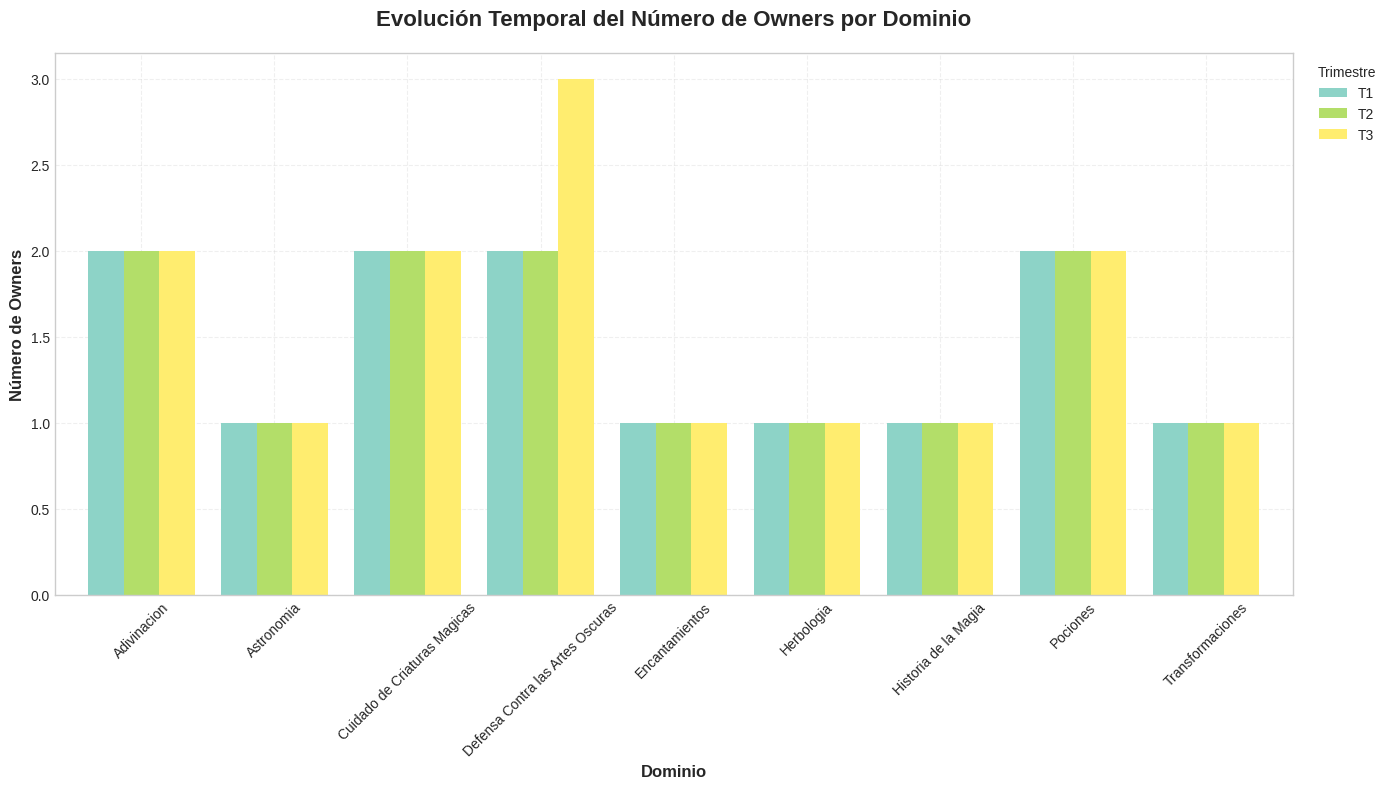

In [17]:
# Evolución temporal del número de Owners por dominio.

# Para graficar esta evolución agrupo por dominio y trimestre, contando los owners únicos
evolucion_owners = df_combinado.groupby(['Trimestre', 'Domain'])['Owner'].nunique().unstack(fill_value=0)

fig4, ax = plt.subplots(figsize=(14, 8))

evolucion_owners.T.plot(
    kind='bar', 
    width=0.8, 
    colormap='Set3',
    linewidth=3,
    ax=ax
    )

ax.set_title('Evolución Temporal del Número de Owners por Dominio', 
          fontsize=16, fontweight='bold', pad=20)

ax.set_xlabel('Dominio', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Owners', fontsize=12, fontweight='bold')

ax.legend(title='Trimestre', loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=10)

ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.grid(axis='both', alpha=0.3, linestyle='--')
fig4.tight_layout()

grafica_evolucion_owners = fig4


**************************************************************

# Segunda Parte

En  esta  sección  se presentarán  los  resultados de cada uno de los apartados propuestos y las visualizaciones convenientes  en tablas  y  gráficos.

### **_Estado actual de los Data Products._**

> ❓ ¿Cuántos  Data  Products  existen  actualmente?  Desglosa  esta  información  por dominio y estado. Queremos saber qué áreas de Hogwarts están mejor (y peor) preparadas.

In [18]:
display(tb_dominio_estado)

Status,Deprecated,Development,Planned,Production,Total
Domain,,,,,
Adivinacion,1,3,2,7,13
Astronomia,1,1,3,2,7
Cuidado de Criaturas Magicas,2,0,2,3,7
Defensa Contra las Artes Oscuras,1,2,6,1,10
Encantamientos,3,3,0,2,8
Herbologia,3,0,6,1,10
Historia de la Magia,3,5,3,1,12
Pociones,3,2,1,5,11
Transformaciones,4,2,1,2,9


Como se observa en la tabla, existen 87 Data Products actualmente (T3), repartidos entre distintas áreas de Hogwards. Para saber qué áreas están mejor preparadas o peor, basta con ver los valores de 'Deprecated' y 'Production', los cuales indican que dichas áreas están deprecated (en riesgo por estar obsoleto) o en producción (área funcionando de forma operativa) respectivamente.

### **_Data Products actuales por dominio y su estado._**

Complementando la tabla anterior, se observa a continuación un gráfico de barras apiladas, en el que es posible observar para cada área el estado en el que se cuentran sus Data Products. Este estado se ha dividido en colores para facilitar su comprensión.

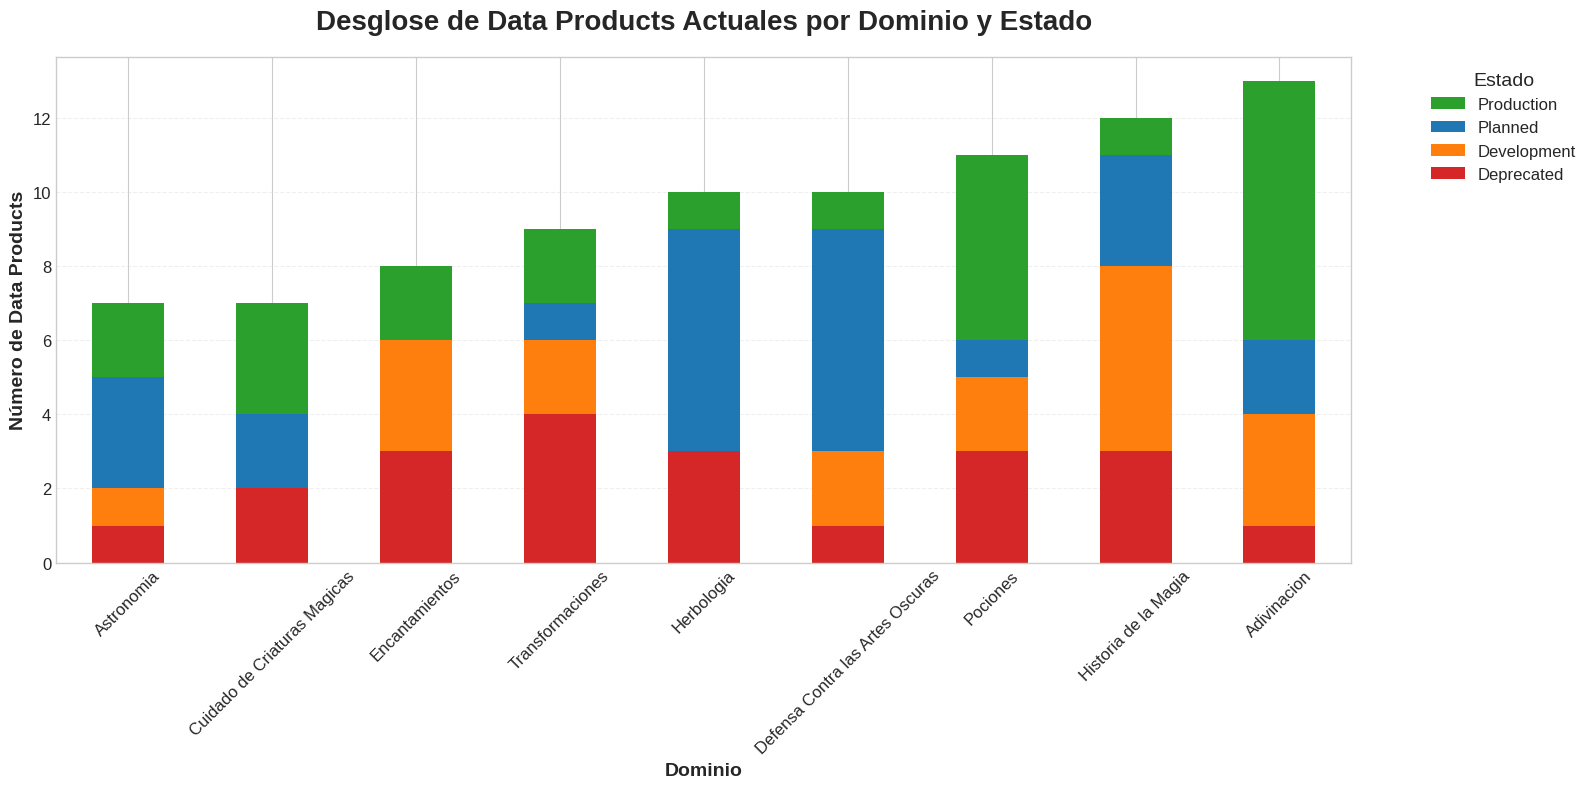

In [19]:
display(grafico_dp_estado)

Gracias a la visualización mostrada anteriormente es posible saber qué areas están peor y mejor preparadas. En el caso de la peor se encuentra "Transformaciones", mientras que la mejor es "Adivinación", ya que tienen un mayor número de Data Products en estado "Deprecated" y "Production" respectivamente. Por otra parte, las áreas "Defensa Contra las Artes oscuras" y "Herbología" muestran un gran número de proyectos planificados, lo que indica un desempeño muy positivo de las mismas.

### **_Análisis trimestral de los Data Products en estado "Planned" o "Production:_**

> ❓ ¿Cuántos de estos cumplen con las normas de compliance?

> ❓ ¿Cuál es el promedio de usuarios por área?

> ❓ ¿Cuántos usuarios están utilizando estos Data Products en cada área?

In [20]:
imprimir_p_p(usuarios_conectados_t)

### Resumen 1: Conteo de Data Products por Cumplimiento (Planned/Production)

,DPs con Compliance,DPs sin Compliance
Trimestre,,
T1,14,12
T2,22,17
T3,28,20


### Resumen 2: Evolución de Usuarios por Dominio (Total y Promedio por Área)

TotalUsuarios           PromedioUsuarios  \
Trimestre                                   T1   T2   T3               T1   
Domain                                                                      
Adivinacion                                259  483  639            64.75   
Astronomia                                 363  463  463            90.75   
Cuidado de Criaturas Magicas               183  262  262            61.00   
Defensa Contra las Artes Oscuras           177  177  598            88.50   
Encantamientos                             200  200  200           100.00   
Herbologia                                 372  468  566            93.00   
Historia de la Magia                        56  190  269            56.00   
Pociones                                   288  368  368            72.00   
Transformaciones                            78  126  126            39.00   

                                                          
Trimestre                                 T2          T3  
Domain                                                    
Adivinacion                        69.000000   71.000000  
Astronomia                         92.600000   92.600000  
Cuidado de Criaturas Magicas       52.400000   52.400000  
Defensa Contra las Artes Oscuras   88.500000   85.428571  
Encantamientos                    100.000000  100.000000  
Herbologia                         78.000000   80.857143  
Historia de la Magia               63.333333   67.250000  
Pociones                           61.333333   61.333333  
Transformaciones                   42.000000   42.000000

> ❓ Y  en  aquellos  que  no  cumplen  con  compliance,  ¿cuántos  usuarios  tienen  de 
todas formas? (¡Esto es importante para identificar posibles brechas de 
seguridad!).

In [27]:
imprimir_no_compliance()

### Resumen 3: Usuarios Conectados a Data Products en Estado No Compliance por Trimestre

,T1,T2,T3
Domain,,,
Adivinacion,113.0,113.0,269.0
Astronomia,68.0,168.0,168.0
Cuidado de Criaturas Magicas,183.0,183.0,183.0
Herbologia,372.0,468.0,566.0
Historia de la Magia,56.0,90.0,90.0
Pociones,NaN,23.0,23.0
Transformaciones,27.0,27.0,27.0
Total,819.0,1072.0,1326.0


### Evolución temporal del número de usuarios de Data Products en producción. 

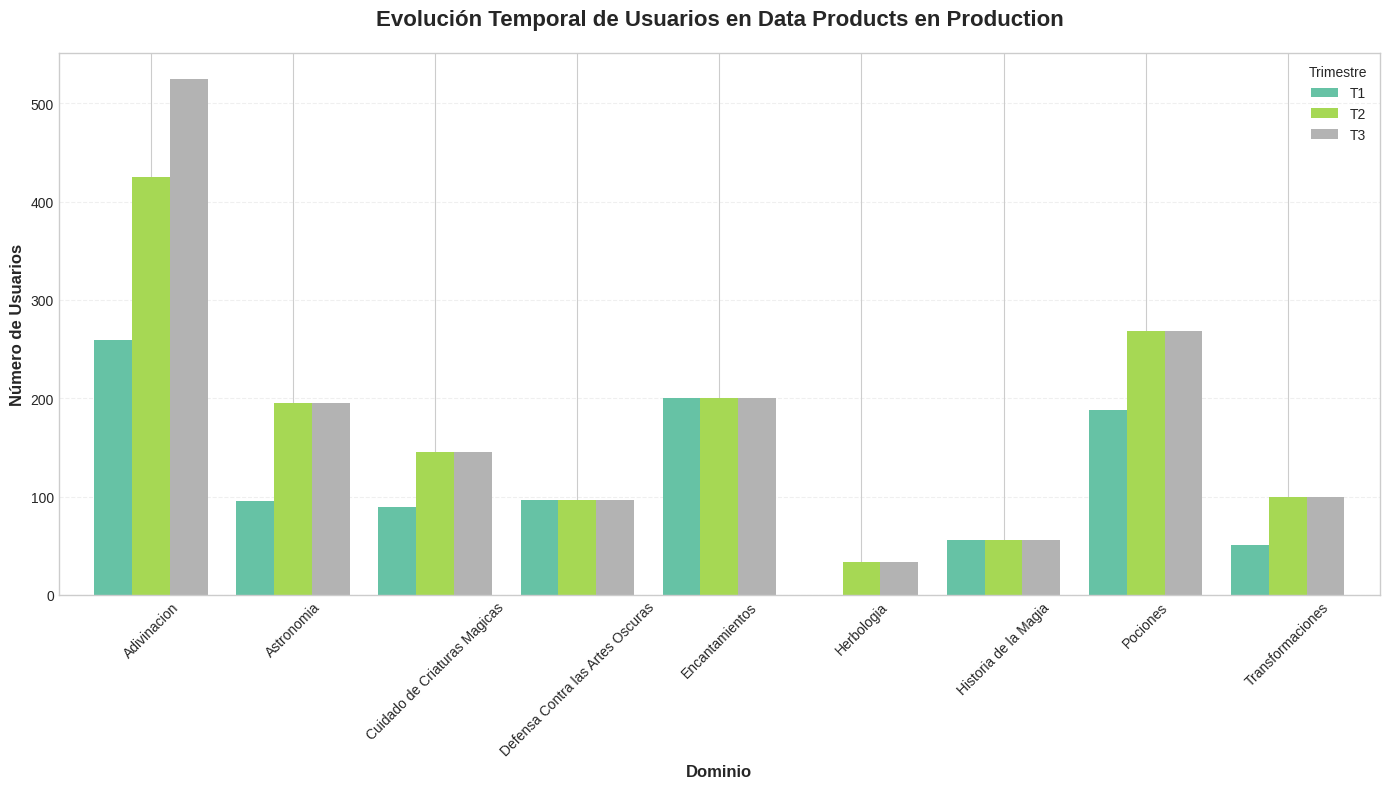

In [28]:
display(grafica_dp_production_users)

A través del gráfico anterior, es posible identificar tres tipos predominantes:
- Crecimiento muy fuerte: Donde se observa el área de Adivinación con un gran crecimiento a lo largo de cada trimestre y el área de pociones, que aunque en menor medida ha presentado crecimiento desde T1.
- Estabilidad: Áreas como Encantamientos, Astronomía y Cuidado de Criaturas mágicas han mostrado un uso constante a lo largo de los trimestres.
- Baja evolución: Donde se encuentran áreas como Herbología e Historia de la Magia, que presentan un número muy bajo de usuarios.

En general, estos resultados muestran un aumento en el número de usuarios, superando o manteniendo los mismos en cada trimestre, donde el uso en T2 superó o igualó al de T1, y el uso en T3 superó o igualó al de T2. Además, no se ha observado en ningún área ninguna caída, lo que sugiere estabilidad en las distintas áreas.

### Evolución  temporal  de  Data  Products  totales  frente  a  aquellos  que  cumplen  con compliance. 

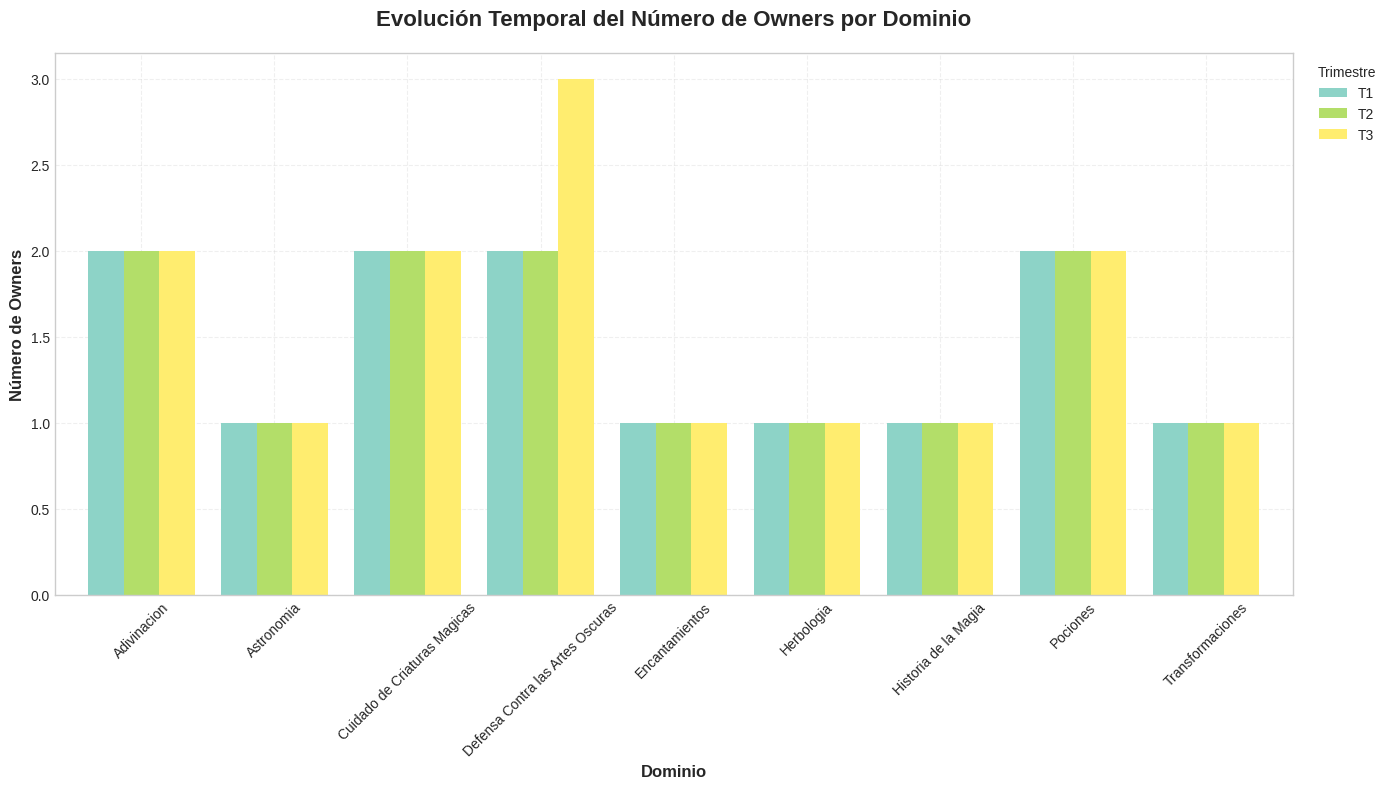

In [29]:
display(grafica_evolucion_owners)

En este gráfico se puede observar cómo el número de Data Products está creciendo cada trimestre, pero no va de la mano con el cumplimiento de la compliance, de forma que la institución, a pesar de que está creciendo mucho, su nivel de cumplimiento de la compliance no lo está haciendo de la misma manera.

### **_Análisis trimestral de los Data Products "Deprecated":_**

> ❓ ¿Cuántos Data Products en estado "Deprecated" hay en cada dominio?

> ❓ ¿Cuántos usuarios siguen conectados a estos Data Products que, oficialmente, 
ya no están en servicio?

In [33]:
imprimir_deprecated_por_dominio(deprecated_por_dominio_t, usuarios_conectados_t)

#### Desglose de Data Products en estado Deprecated en T1

**Número de usuarios conectados a Data Products en estado 'Deprecated' en T1: 668**

,Número de Data Products Deprecated
Domain,
Herbologia,3
Pociones,2
Transformaciones,2
Historia de la Magia,2
Encantamientos,2
Adivinacion,1


#### Desglose de Data Products en estado Deprecated en T2

**Número de usuarios conectados a Data Products en estado 'Deprecated' en T2: 959**

,Número de Data Products Deprecated
Domain,
Transformaciones,4
Herbologia,3
Encantamientos,3
Pociones,2
Historia de la Magia,2
Adivinacion,1
Defensa Contra las Artes Oscuras,1
Cuidado de Criaturas Magicas,1


#### Desglose de Data Products en estado Deprecated en T3

**Número de usuarios conectados a Data Products en estado 'Deprecated' en T3: 1171**

,Número de Data Products Deprecated
Domain,
Transformaciones,4
Pociones,3
Herbologia,3
Historia de la Magia,3
Encantamientos,3
Cuidado de Criaturas Magicas,2
Adivinacion,1
Defensa Contra las Artes Oscuras,1
Astronomia,1


En este apartado, es posible identificar una clara tendencia alcista del número de usuarios conectados a Data Products en estado Deprecated, pasando de 668 en T1 a 1171 en T3.

Por otra parte, es posible observar también cómo las áreas van cambiando según el trimestre, ya que en T2 se encuentran dos nuevas áreas, "Defensa Contra las Artes Oscuras" y "Cuidado de Criaturas Mágicas", además de las de T1. Por último, en T3 se añade una más respecto a T2, "Astronomía". Todo esto sugiere que a medida que pasa el tiempo se procuden más estados "Deprecated" en los Data Products en general, lo cual incrementa el número de áreas afectadas, ya que por ejemplo en T1 no había ningún DP en estado Deprecated en el área de Astronomía.

### **_Análisis de los funcionarios (Owners) por cada trimestre:_**

> ❓ ¿Cuántos funcionarios están trabajando, y cuántos Data Products (por estado) 
tienen asignados?

In [34]:
owners_por_dominio(tb_owner_estado_t)

#### Número de Owners únicos trabajando en T1: 12

#### Desglose Trimestre T1

Status,Deprecated,Development,Planned,Production,Total
Owner,,,,,
Alastor Moody,0,0,0,1,1
Aurora Sinistra,0,0,3,1,4
Cuthbert Binns,2,3,0,1,6
Filius Flitwick,2,1,0,2,5
Firenze,0,1,0,2,3
Horace Slughorn,0,1,1,1,3
Minerva McGonagall,2,2,1,1,6
Pomona Sprout,3,0,4,0,7
Rubeus Hagrid,0,0,1,1,2


#### Número de Owners únicos trabajando en T2: 12

#### Desglose Trimestre T2

Status,Deprecated,Development,Planned,Production,Total
Owner,,,,,
Alastor Moody,1,0,0,1,2
Aurora Sinistra,0,1,3,2,6
Cuthbert Binns,2,4,2,1,9
Filius Flitwick,3,1,0,2,6
Firenze,0,1,0,3,4
Horace Slughorn,0,1,1,2,4
Minerva McGonagall,4,2,1,2,9
Pomona Sprout,3,0,5,1,9
Rubeus Hagrid,0,0,2,2,4


#### Número de Owners únicos trabajando en T3: 13

#### Desglose Trimestre T3

Status,Deprecated,Development,Planned,Production,Total
Owner,,,,,
Alastor Moody,1,0,1,1,3
Aurora Sinistra,1,1,3,2,7
Cuthbert Binns,3,5,3,1,12
Filius Flitwick,3,3,0,2,8
Firenze,0,1,1,4,6
Horace Slughorn,0,1,1,2,4
Minerva McGonagall,4,2,1,2,9
Pomona Sprout,3,0,6,1,10
Remus Lupin,0,1,1,0,2


> ❓ En cada dominio, ¿quiénes son los tres Owners  con más usuarios en sus Data 
Products en estado "Planned" o "Production"? 

In [35]:
imprimir_top3_owners(top3_por_trimestre)

### Top 3 Owners por Número de Usuarios en Data Products (Planned/Production) - T1

,Owner,Usuarios,Domain
0,Firenze,150,Adivinacion
1,Sybill Trelawney,109,Adivinacion
2,Severus Snape,156,Pociones
3,Horace Slughorn,132,Pociones
4,Minerva McGonagall,78,Transformaciones
5,Pomona Sprout,372,Herbologia
6,Cuthbert Binns,56,Historia de la Magia
7,Rubeus Hagrid,168,Cuidado de Criaturas Magicas
8,Wilhelmina Grubbly-Plank,15,Cuidado de Criaturas Magicas
9,Alastor Moody,96,Defensa Contra las Artes Oscuras


### Top 3 Owners por Número de Usuarios en Data Products (Planned/Production) - T2

,Owner,Usuarios,Domain
0,Sybill Trelawney,267,Adivinacion
1,Firenze,216,Adivinacion
2,Horace Slughorn,189,Pociones
3,Severus Snape,179,Pociones
4,Minerva McGonagall,126,Transformaciones
5,Pomona Sprout,468,Herbologia
6,Cuthbert Binns,190,Historia de la Magia
7,Rubeus Hagrid,247,Cuidado de Criaturas Magicas
8,Wilhelmina Grubbly-Plank,15,Cuidado de Criaturas Magicas
9,Alastor Moody,96,Defensa Contra las Artes Oscuras


### Top 3 Owners por Número de Usuarios en Data Products (Planned/Production) - T3

,Owner,Usuarios,Domain
0,Firenze,372,Adivinacion
1,Sybill Trelawney,267,Adivinacion
2,Horace Slughorn,189,Pociones
3,Severus Snape,179,Pociones
4,Minerva McGonagall,126,Transformaciones
5,Pomona Sprout,566,Herbologia
6,Cuthbert Binns,269,Historia de la Magia
7,Rubeus Hagrid,247,Cuidado de Criaturas Magicas
8,Wilhelmina Grubbly-Plank,15,Cuidado de Criaturas Magicas
9,Severus Snape,331,Defensa Contra las Artes Oscuras


> ❓ Por  otro  lado,  ¿quién  es  el  Owner  menos  productivo  en  cada  dominio?  Esto 
significa que tiene el mayor porcentaje de Data Products en estado 
"Deprecated"  sobre  el  total  que  le  han  asignado.  Si  hay  empate,  ¡queremos 
saber todos los nombres! 

In [36]:
display(tb_least_productive_final)

,Owner,TotalDP,DeprecatedDP,PorcentajeDeprecated,Trimestre,Domain
0,Sybill Trelawney,5,1,20.000000,T1,Adivinacion
1,Severus Snape,5,2,40.000000,T1,Pociones
2,Minerva McGonagall,6,2,33.333333,T1,Transformaciones
3,Pomona Sprout,7,3,42.857143,T1,Herbologia
4,Cuthbert Binns,6,2,33.333333,T1,Historia de la Magia
5,Filius Flitwick,5,2,40.000000,T1,Encantamientos
6,Sybill Trelawney,7,1,14.285714,T2,Adivinacion
7,Severus Snape,6,2,33.333333,T2,Pociones
8,Minerva McGonagall,9,4,44.444444,T2,Transformaciones
9,Pomona Sprout,9,3,33.333333,T2,Herbologia


> ❓ Y  finalmente,  debido a la importancia de  la ubicuidad, ¿hay  algún funcionario 
que  esté trabajando en varios dominios a la vez? El Ministerio quiere saber si 
tiene a algún mago "polifacético" en su equipo.

In [37]:
owners_multiples_dominios(owners_multiples_t3)

### Owners trabajando en múltiples dominios - T1

,Número de Dominios
Owner,
Severus Snape,2


### Owners trabajando en múltiples dominios - T2

,Número de Dominios
Owner,
Severus Snape,2


### Owners trabajando en múltiples dominios - T3

,Número de Dominios
Owner,
Severus Snape,2


El único owner que ha estado en más de una área, en concreto en 2 a lo largo de los tres trimestres ha sido Severus Snape.

### Evolución temporal del número de Owners por dominio. 

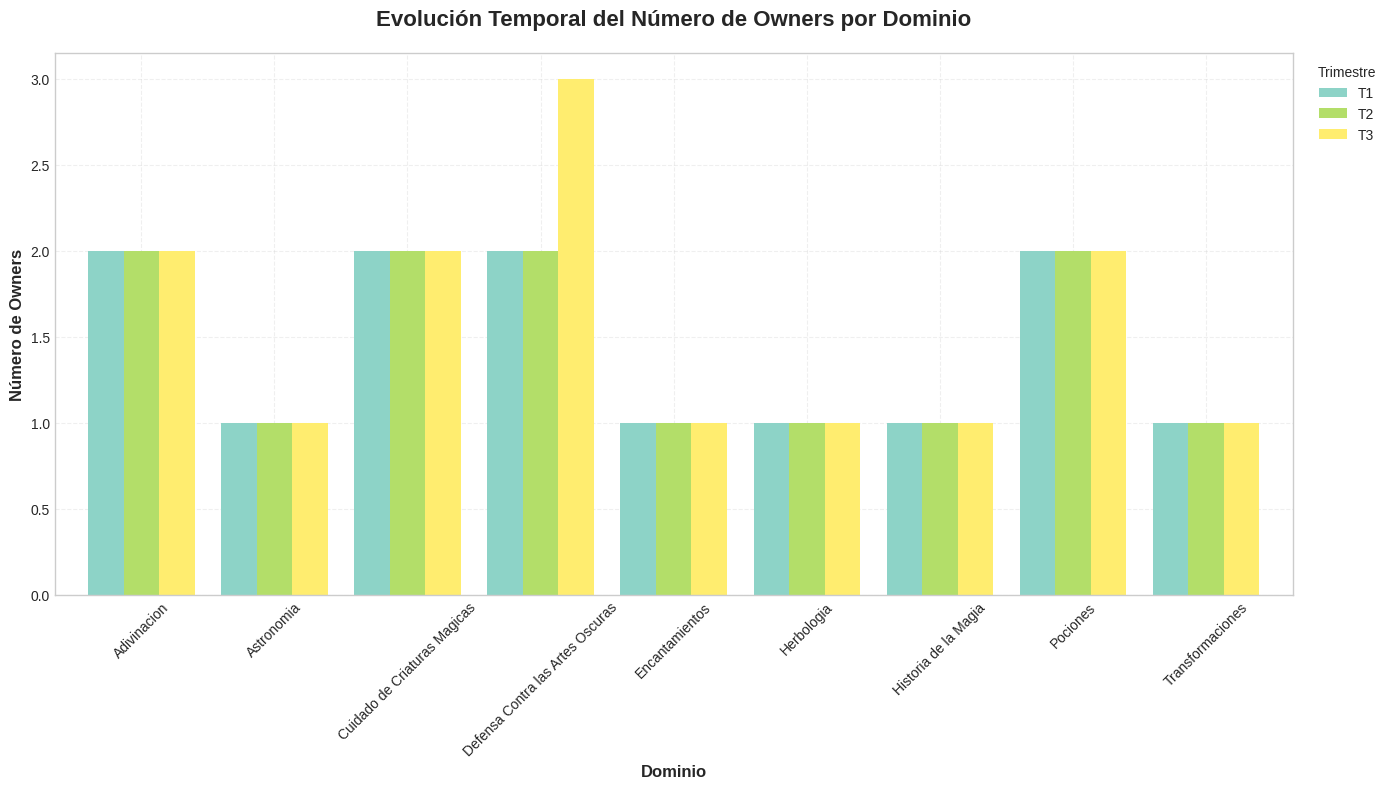

In [38]:
display(grafica_evolucion_owners)

En esta gráfica se puede observar cómo el número de owners se mantiene constante a lo largo de los tres trimestres, a excepción del área de Defensa Contra las Artes Oscuras, donde se observa un claro crecimiento en el tercer trimestre (T3).

La gran mayoría de dominios muestran un número constante de owners, normalmente entre 1 y 2 a lo largo de los tres trimestres, excepto el área de Defensa contra las artes oscuras, donde hay un pico en el tercer trimestre, lo que puede estar relacionado con el aumento de Data Products en estado Planned.